# Sliding-Window Forecast: Multi-Checkpoint Comparison

This notebook draws only the main sliding-window count forecast for each checkpoint in one multi-panel figure. It reuses the model catalog from `forecast_nxm.ipynb` and is cache-first: compatible `sliding_window_cache*.npz` files are read from each checkpoint directory before any model sampling is attempted.

The default settings target the test interval. Set `ALLOW_CACHE_RECOMPUTE = True` only when a compatible cache is unavailable and a replacement cache should be generated in that checkpoint directory.

## 1) Setup

In [25]:
import gc
import inspect
import json
import os
import re
import sys
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Cannot find project root containing src directory.')


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.updaters import UpdaterSamplingWrapper, build_sampling_updater
from src.train.config_setup import load_and_prepare_model
from src.utils.forecast_eval import (
    SlidingWindowEvaluationRange,
    apply_publication_style,
    build_sliding_cache_metadata,
    compute_mean_crps,
    compute_mean_nb_log_prob,
    evaluate_sliding_window_forecast_plots,
    load_sliding_window_cache_if_compatible,
    save_pub_figure,
)
from src.utils.runtime_utils import unwrap_compiled_model
from src.utils.tpp_experiments import load_tpp_catalog

apply_publication_style()
plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 7.5,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
})

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / 'forecast_sliding_window'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0
OUTPUT_DIR: /root/autodl-tmp/em_eqf/notebooks/figs/forecast_sliding_window


## 2) Checkpoints

In [26]:
MODEL_SPEC_NOTEBOOK_NAME = 'forecast_nxm'
DEFAULT_MODEL_SPEC_CONFIG_NAME = 'St1_2018_full' #'CB_HAB1a_full' #'CB_HAB4_full' # 'PNR_1z_full'
MODEL_SPEC_CONFIG_NAME = os.environ.get(
    'MODEL_SPEC_CONFIG_NAME',
    DEFAULT_MODEL_SPEC_CONFIG_NAME,
)
MODEL_SPEC_CONFIG_PATH = (
    PROJECT_ROOT
    / 'notebooks'
    / 'config'
    / 'model_specs'
    / MODEL_SPEC_NOTEBOOK_NAME
    / f'model_specs.{MODEL_SPEC_NOTEBOOK_NAME}.v1.json'
)


def resolve_ckpt_path(path_like) -> Path:
    path = Path(path_like).expanduser()
    return path if path.is_absolute() else PROJECT_ROOT / path


def load_checkpoint_specs(config_path: Path, config_name: str):
    if not config_path.exists():
        raise FileNotFoundError(f'Model spec config file not found: {config_path}')
    with open(config_path, 'r', encoding='utf-8') as handle:
        catalog = json.load(handle)

    configs = catalog.get('configs', {})
    if config_name not in configs:
        available = ', '.join(sorted(configs))
        raise KeyError(
            f'Unknown MODEL_SPEC_CONFIG_NAME={config_name}. Available: {available}'
        )

    selected = configs[config_name]
    models = selected.get('models', [])
    if not isinstance(models, list) or not models:
        raise ValueError(f'Config {config_name!r} has no checkpoint models.')

    specs = []
    for index, item in enumerate(models):
        path = item.get('checkpoint_rel_path', item.get('path'))
        label = item.get('label')
        if not path or not label:
            raise KeyError(
                f'Model item {index} in config {config_name!r} needs label and path.'
            )
        specs.append({'label': str(label), 'path': path})
    return selected, specs


selected_model_spec_cfg, CKPT_SPECS = load_checkpoint_specs(
    MODEL_SPEC_CONFIG_PATH,
    MODEL_SPEC_CONFIG_NAME,
)
print(f'Loaded config: {MODEL_SPEC_CONFIG_NAME}')
if selected_model_spec_cfg.get('description'):
    print(selected_model_spec_cfg['description'])
for spec in CKPT_SPECS:
    checkpoint_path = resolve_ckpt_path(spec['path'])
    status = 'OK' if checkpoint_path.exists() else 'MISSING'
    print(f'{status}: {spec["label"]}: {checkpoint_path}')

Loaded config: St1_2018_full
St1-2018 forecast comparison: ETAS family + RECAST family + Oracle
OK: ETAS: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_no_bg_seed_1/best_model_1.pth
OK: RECAST: /root/autodl-tmp/em_eqf/experiments/rtpp_v2_multi_bg_split_0.7/runs/rtpp_v2_bg_St1_2018_no_bg_seed_2/best_model_1.pth
OK: Oracle: /root/autodl-tmp/em_eqf/experiments/oracle_multi_dataset_0.7/runs/oracle_St1_2018_seed_0/best_model_1.pth
OK: ETAS + p: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_proportional_seed_1/best_model_1.pth
OK: ETAS + conv: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_kernel_seed_1/best_model_1.pth
OK: ETAS + Mamba: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_mamba_seed_1/best_model_1.pth
OK: RECAST + p: /root/autodl-tmp/em_eqf/experiments/rtpp_v2_multi_bg_split_0.7/runs/rtpp_v2_bg_St1_2018_proportional_seed_2/best_model_1.

## 3) Sliding-Window and Cache Settings

In [27]:
SLIDING_DURATION = 1
SLIDING_STEP = 1
SLIDING_QUANTILES = (2.5, 97.5)
SAMPLES_PER_BATCH = 1000
INCLUDE_TRUNCATED_FINAL_WINDOW = False

# Supported values: 'test' and 'full'. The test interval starts at metadata.test_start_t.
EVALUATION_RANGE_NAME = 'full'

# Cache-first mode. Set this to True only when a missing cache should be recomputed.
ALLOW_CACHE_RECOMPUTE = False

# None scans each checkpoint directory. Set an explicit filename only when all
# selected checkpoint directories contain the same cache filename.
CHECKPOINT_CACHE_FILENAME = None
FORECAST_B_SAMPLING = 'model'
UPDATER_NAME = 'bayesian_gr'
CHECKPOINT_CACHE_GLOB = f'sliding_window_cache_{FORECAST_B_SAMPLING}_*.npz'

# These settings are used only by the optional recomputation fallback.
MODEL_MM = 4
UPDATER_CFG = {
    'delta': 0.98,
    'a0': 50,
    'init_b_target': 1,
}

# Use the forecast_nxm-style grid in the full text width of a single-column paper.
N_COLS = 3

print(f'Window: next {SLIDING_DURATION:g}; step: {SLIDING_STEP:g}')
print(f'Evaluation range: {EVALUATION_RANGE_NAME}')
print(f'Cache recomputation enabled: {ALLOW_CACHE_RECOMPUTE}')

Window: next 1; step: 1
Evaluation range: full
Cache recomputation enabled: False


## 4) Load Catalog and Resolve Evaluation Range

In [28]:
bootstrap_path = resolve_ckpt_path(CKPT_SPECS[0]['path'])
bootstrap_model, bootstrap_args = load_and_prepare_model(
    checkpoint_path=bootstrap_path,
    device=DEVICE,
    compile=False,
)
bootstrap_model = unwrap_compiled_model(bootstrap_model)

catalog_cfg = getattr(bootstrap_args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    bootstrap_args.dataset,
    base_dir=PROJECT_ROOT / 'data' / bootstrap_args.dataset,
    catalog_cfg=catalog_cfg,
)

del bootstrap_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

sequences = catalog_ds.sequences if hasattr(catalog_ds, 'sequences') else [catalog_ds.full_sequence]
SEQUENCE_IDX = 0
seq = sequences[SEQUENCE_IDX]
metadata = catalog_ds.metadata


def metadata_value(name, default=None):
    if hasattr(metadata, 'get'):
        return metadata.get(name, default)
    return getattr(metadata, name, default)


def resolve_requested_evaluation_range():
    requested_name = str(EVALUATION_RANGE_NAME).strip().lower()
    if requested_name == 'full':
        return None
    if requested_name == 'test':
        test_start = metadata_value('test_start_t')
        if test_start is None:
            raise KeyError('Catalog metadata has no test_start_t for test evaluation.')
        return SlidingWindowEvaluationRange(
            name='test',
            start=float(test_start),
            end=float(seq.t_end),
            grid_anchor=float(test_start),
        )
    raise ValueError('EVALUATION_RANGE_NAME must be test or full.')


REQUESTED_EVALUATION_RANGE = resolve_requested_evaluation_range()
date_label = pd.Timestamp(metadata_value('start_ts')).strftime('%Y-%m-%d')

print(f'Catalog registry: {registry_name}')
print(f'Dataset: {bootstrap_args.dataset}')
print(f'Sequence bounds: [{float(seq.t_start):.6f}, {float(seq.t_end):.6f}]')
if REQUESTED_EVALUATION_RANGE is not None:
    print(
        'Requested test range: '
        f'[{REQUESTED_EVALUATION_RANGE.start:.6f}, {REQUESTED_EVALUATION_RANGE.end:.6f}]'
    )

/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Catalog registry: St1-2018-Standard
Dataset: St1-2018
Sequence bounds: [0.000000, 78.772598]


## 5) Load Compatible Checkpoint Caches

In [29]:
def _cache_scalar(data, key):
    return np.asarray(data[key]).item()


def _predict_b_from_cache(value):
    value = int(value)
    return None if value < 0 else bool(value)


def _sampling_seed_from_checkpoint_dir(checkpoint_dir: Path):
    match = re.search(r'_seed_(\d+)$', checkpoint_dir.name)
    return None if match is None else int(match.group(1))


def _cache_candidates(checkpoint_dir: Path):
    if CHECKPOINT_CACHE_FILENAME is not None:
        return [checkpoint_dir / CHECKPOINT_CACHE_FILENAME]
    return sorted(path for path in checkpoint_dir.glob(CHECKPOINT_CACHE_GLOB) if path.is_file())


def _candidate_matches_requested_settings(data, cache_version: int):
    required = {
        'duration', 'slide_step', 'quantile_low', 'quantile_high',
        'samples_per_batch', 'predict_b_mode', 'seq_start', 'seq_end',
    }
    if not required.issubset(data.files):
        return False

    float_checks = (
        ('duration', SLIDING_DURATION),
        ('slide_step', SLIDING_STEP),
        ('quantile_low', SLIDING_QUANTILES[0]),
        ('quantile_high', SLIDING_QUANTILES[1]),
    )
    for key, expected in float_checks:
        if not np.isclose(float(_cache_scalar(data, key)), float(expected), rtol=0.0, atol=1e-9):
            return False
    if int(_cache_scalar(data, 'samples_per_batch')) != int(SAMPLES_PER_BATCH):
        return False

    if cache_version == 2:
        return str(EVALUATION_RANGE_NAME).strip().lower() == 'full'

    required_v4 = {
        'include_truncated_final_window', 'evaluation_name',
        'evaluation_start', 'evaluation_end', 'evaluation_grid_anchor',
        'sampling_seed', 'seq_t_start', 'seq_t_end',
    }
    if not required_v4.issubset(data.files):
        return False
    if int(_cache_scalar(data, 'include_truncated_final_window')) != int(INCLUDE_TRUNCATED_FINAL_WINDOW):
        return False
    if str(_cache_scalar(data, 'evaluation_name')).strip().lower() != str(EVALUATION_RANGE_NAME).strip().lower():
        return False

    if REQUESTED_EVALUATION_RANGE is not None:
        cache_start = float(_cache_scalar(data, 'evaluation_start'))
        cache_anchor = float(_cache_scalar(data, 'evaluation_grid_anchor'))
        if not np.isclose(cache_start, float(REQUESTED_EVALUATION_RANGE.start), rtol=0.0, atol=1e-9):
            return False
        if not np.isclose(cache_anchor, float(REQUESTED_EVALUATION_RANGE.grid_anchor), rtol=0.0, atol=1e-9):
            return False
        # A cached background grid may end one grid point before seq.t_end.
        cache_end = float(_cache_scalar(data, 'evaluation_end'))
        if cache_end > float(REQUESTED_EVALUATION_RANGE.end) + 1e-9:
            return False
    return True


def _metadata_from_cache(data, cache_version: int):
    if cache_version == 2:
        cache_range = None
        sampling_seed = None
    else:
        cache_range = SlidingWindowEvaluationRange(
            name=str(_cache_scalar(data, 'evaluation_name')),
            start=float(_cache_scalar(data, 'evaluation_start')),
            end=float(_cache_scalar(data, 'evaluation_end')),
            grid_anchor=float(_cache_scalar(data, 'evaluation_grid_anchor')),
        )
        cached_seed = int(_cache_scalar(data, 'sampling_seed'))
        sampling_seed = None if cached_seed < 0 else cached_seed

    return build_sliding_cache_metadata(
        seq,
        duration=float(_cache_scalar(data, 'duration')),
        slide_step=float(_cache_scalar(data, 'slide_step')),
        quantiles=(
            float(_cache_scalar(data, 'quantile_low')),
            float(_cache_scalar(data, 'quantile_high')),
        ),
        samples_per_batch=int(_cache_scalar(data, 'samples_per_batch')),
        include_truncated_final_window=(
            False if cache_version == 2 else bool(_cache_scalar(data, 'include_truncated_final_window'))
        ),
        evaluation_range=cache_range,
        predict_b=_predict_b_from_cache(_cache_scalar(data, 'predict_b_mode')),
        sampling_seed=sampling_seed,
    )


def load_checkpoint_cache(checkpoint_dir: Path):
    candidate_paths = _cache_candidates(checkpoint_dir)
    for cache_path in candidate_paths:
        try:
            with np.load(cache_path, allow_pickle=False) as data:
                if 'cache_version' not in data.files:
                    continue
                cache_version = int(_cache_scalar(data, 'cache_version'))
                if not _candidate_matches_requested_settings(data, cache_version):
                    continue
                cache_metadata = _metadata_from_cache(data, cache_version)
        except (OSError, ValueError, KeyError, TypeError):
            continue

        payload = load_sliding_window_cache_if_compatible(
            cache_path,
            metadata=cache_metadata,
        )
        if payload is None:
            continue

        return {
            't_forecast_list': np.asarray(payload.t_forecast, dtype=float),
            't_window_end_list': getattr(payload, 't_window_end', None),
            'counts_list': np.asarray(payload.counts, dtype=float),
            'q_list': np.asarray(payload.quantiles, dtype=float),
            'mean_list': np.asarray(payload.mean, dtype=float),
            'sim_count_matrix': (
                None
                if payload.sim_count_matrix is None
                else np.asarray(payload.sim_count_matrix, dtype=float)
            ),
            'sliding_cache_path': str(cache_path),
            'sliding_loaded_from_cache': True,
        }
    return None


def supports_dynamic_b_sampling(model) -> bool:
    try:
        parameters = inspect.signature(model.sample).parameters
        return any(
            name in parameters
            for name in ('b_sampling', 'updater', 'updater_name', 'updater_cfg')
        )
    except (TypeError, ValueError):
        return hasattr(model, '_normalize_b_sampling_mode')


def make_recompute_sampling_model(model, args):
    if MODEL_MM is not None and hasattr(model, 'M_m'):
        model.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)
    predict_b = bool(getattr(args, 'predict_b', False))
    if hasattr(model, 'predict_b'):
        model.predict_b = predict_b

    if FORECAST_B_SAMPLING != 'updater' or not supports_dynamic_b_sampling(model):
        return model, predict_b

    def updater_factory():
        return build_sampling_updater(
            model=model,
            mc=float(metadata_value('mag_completeness')),
            updater_name=UPDATER_NAME,
            updater_cfg=dict(UPDATER_CFG),
            device=getattr(model, 'device', DEVICE),
        )

    return UpdaterSamplingWrapper(
        model,
        sampling_mode=FORECAST_B_SAMPLING,
        updater_factory=updater_factory,
    ), predict_b


def recompute_checkpoint_cache(spec):
    checkpoint_path = resolve_ckpt_path(spec['path'])
    checkpoint_dir = checkpoint_path.parent
    model, args = load_and_prepare_model(
        checkpoint_path=checkpoint_path,
        device=DEVICE,
        compile=False,
    )
    model = unwrap_compiled_model(model)
    if str(getattr(args, 'dataset', '')) != str(bootstrap_args.dataset):
        raise ValueError(
            f'{spec["label"]} uses dataset={getattr(args, "dataset", None)}, '
            f'expected {bootstrap_args.dataset}.'
        )

    sampling_model, predict_b = make_recompute_sampling_model(model, args)
    cache_tag = UPDATER_NAME if FORECAST_B_SAMPLING == 'updater' else 'model'
    cache_filename = (
        f'sliding_window_cache_{FORECAST_B_SAMPLING}_{cache_tag}_'
        f'{EVALUATION_RANGE_NAME}.npz'
    )
    result = evaluate_sliding_window_forecast_plots(
        model=sampling_model,
        seq=seq,
        device=DEVICE,
        catalog_ds=catalog_ds,
        checkpoint_dir=checkpoint_dir,
        sliding_duration=SLIDING_DURATION,
        sliding_step=SLIDING_STEP,
        sliding_quantiles=SLIDING_QUANTILES,
        samples_per_batch=SAMPLES_PER_BATCH,
        include_truncated_final_window=INCLUDE_TRUNCATED_FINAL_WINDOW,
        evaluation_range=REQUESTED_EVALUATION_RANGE,
        predict_b=predict_b,
        bg_cache_seq=seq,
        load_sliding_cache=True,
        force_recompute_sliding=False,
        sliding_cache_filename=cache_filename,
        sampling_seed=_sampling_seed_from_checkpoint_dir(checkpoint_dir),
        save_plots=False,
    )

    del sampling_model
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if result.get('status') == 'empty':
        raise RuntimeError(f'{spec["label"]}: {result["message"]}')
    return result


sliding_results_by_label = OrderedDict()
summary_rows = []
missing_cache_messages = []

for index, spec in enumerate(CKPT_SPECS, start=1):
    checkpoint_path = resolve_ckpt_path(spec['path'])
    if not checkpoint_path.exists():
        missing_cache_messages.append(
            f'{spec["label"]}: checkpoint is missing: {checkpoint_path}'
        )
        continue

    checkpoint_dir = checkpoint_path.parent
    result = load_checkpoint_cache(checkpoint_dir)
    if result is None and ALLOW_CACHE_RECOMPUTE:
        print(f'[{index}/{len(CKPT_SPECS)}] recomputing cache for {spec["label"]}')
        result = recompute_checkpoint_cache(spec)
    if result is None:
        candidates = [path.name for path in _cache_candidates(checkpoint_dir)]
        missing_cache_messages.append(
            f'{spec["label"]}: no compatible cache in {checkpoint_dir} '
            f'(candidates={candidates or "none"})'
        )
        continue

    counts = np.asarray(result['counts_list'], dtype=float)
    quantiles = np.asarray(result['q_list'], dtype=float)
    means = np.asarray(result['mean_list'], dtype=float)
    sim_counts = result.get('sim_count_matrix')
    coverage = float(np.mean((counts >= quantiles[:, 0]) & (counts <= quantiles[:, 1])))
    if sim_counts is None:
        crps = float(result.get('crps', np.nan))
        lp_nb = float(result.get('lp_nb', np.nan))
    else:
        crps, _ = compute_mean_crps(counts, sim_counts)
        lp_nb, _ = compute_mean_nb_log_prob(counts, sim_counts)
    result['metrics'] = {
        'coverage': coverage,
        'mae': float(np.mean(np.abs(counts - means))),
        'rmse': float(np.sqrt(np.mean((counts - means) ** 2))),
        'crps': float(crps),
        'w95': float(np.mean(quantiles[:, 1] - quantiles[:, 0])),
        'lp_nb': float(lp_nb),
    }
    sliding_results_by_label[spec['label']] = result
    summary_rows.append({
        'label': spec['label'],
        'num_windows': len(counts),
        'coverage': coverage,
        **result['metrics'],
        'cache': result['sliding_cache_path'],
        'loaded_from_cache': bool(result['sliding_loaded_from_cache']),
    })
    state = 'loaded' if result['sliding_loaded_from_cache'] else 'computed and saved'
    print(f'[{index}/{len(CKPT_SPECS)}] {spec["label"]}: {state}: {result["sliding_cache_path"]}')

if missing_cache_messages:
    details = '\n'.join(f'  - {message}' for message in missing_cache_messages)
    raise FileNotFoundError(
        'Compatible sliding-window cache is required by default. '
        'Set ALLOW_CACHE_RECOMPUTE = True to create missing caches.\n'
        + details
    )

cache_summary_df = pd.DataFrame(summary_rows)
cache_summary_df

[1/9] ETAS: loaded: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_no_bg_seed_1/sliding_window_cache_model_model_full_9c4169d4da73.npz
[2/9] RECAST: loaded: /root/autodl-tmp/em_eqf/experiments/rtpp_v2_multi_bg_split_0.7/runs/rtpp_v2_bg_St1_2018_no_bg_seed_2/sliding_window_cache_model_model.npz
[3/9] Oracle: loaded: /root/autodl-tmp/em_eqf/experiments/oracle_multi_dataset_0.7/runs/oracle_St1_2018_seed_0/sliding_window_cache_model_model.npz
[4/9] ETAS + p: loaded: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_proportional_seed_1/sliding_window_cache_model_model_full_9c4169d4da73.npz
[5/9] ETAS + conv: loaded: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_kernel_seed_1/sliding_window_cache_model_model_full_9c4169d4da73.npz
[6/9] ETAS + Mamba: loaded: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_mamba_seed_1/sliding_window_cache_model_model_ful

,label,num_windows,coverage,mae,rmse,crps,w95,lp_nb,cache,loaded_from_cache
0,ETAS,74,0.905405,144.380081,221.322946,102.435159,687.561149,-6.108202,/root/autodl-tmp/em_eqf/experiments/etas_multi...,True
1,RECAST,74,0.716216,170.278649,206.602470,116.744217,599.496622,-7.033697,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...,True
2,Oracle,74,0.608108,107.556014,158.395886,85.698020,255.545608,-8.813599,/root/autodl-tmp/em_eqf/experiments/oracle_mul...,True
3,ETAS + p,74,0.891892,86.320676,121.358368,61.260497,290.410473,-5.739878,/root/autodl-tmp/em_eqf/experiments/etas_multi...,True
4,ETAS + conv,74,0.945946,81.024689,117.369002,56.970972,343.986149,-5.592964,/root/autodl-tmp/em_eqf/experiments/etas_multi...,True
5,ETAS + Mamba,74,0.702703,86.727811,118.515561,67.370547,207.261149,-6.372570,/root/autodl-tmp/em_eqf/experiments/etas_multi...,True
6,RECAST + p,74,0.783784,73.050730,101.007859,52.517476,279.912500,-6.035430,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...,True
7,RECAST + conv,74,0.918919,83.351959,123.460931,59.451213,313.360811,-5.545892,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...,True
8,RECAST + Mamba,74,0.608108,71.120770,94.187923,55.083966,149.403378,-7.197395,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...,True


## 6) Main Sliding-Window Forecast Figure

Saved: /root/autodl-tmp/em_eqf/notebooks/figs/forecast_sliding_window/sliding_forecast_St1_2018_full_full_3col.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/forecast_sliding_window/sliding_forecast_St1_2018_full_full_3col.png


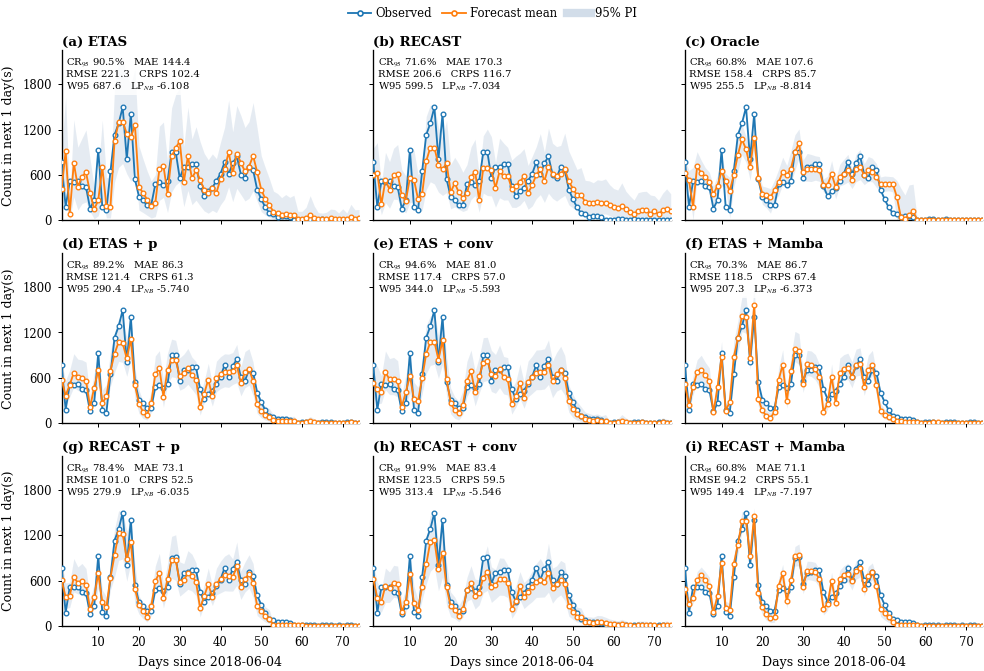

In [30]:
PLOT_COLORS = {
    'observed': '#1f77b4',
    'forecast': '#ff7f0e',
    'interval': '#4c78a8',
}

# Slightly wider and shorter than the default forecast_nxm export, while
# preserving its 3-column panel arrangement.
SINGLE_COLUMN_PAPER_WIDTH_IN = 8.25
PANEL_HEIGHT_IN = 1.68


def panel_label(index: int, label: str) -> str:
    return f'({chr(ord("a") + index)}) {str(label).replace("mamba", "Mamba")}'


def common_count_ylim(results_by_label):
    candidates = [0.0]
    for result in results_by_label.values():
        candidates.extend(np.asarray(result['counts_list'], dtype=float))
        candidates.extend(np.asarray(result['mean_list'], dtype=float))
        candidates.extend(np.asarray(result['q_list'], dtype=float).reshape(-1))
    ymax = float(np.nanmax(np.asarray(candidates, dtype=float)))
    return 0.0, max(1.0, ymax * 1.05)


def format_metric(value, format_spec):
    return 'N/A' if value is None or not np.isfinite(value) else format(value, format_spec)


def panel_metrics_text(result):
    metrics = result['metrics']
    return (
        f"CR$_{{95}}$ {metrics['coverage']:.1%}   MAE {metrics['mae']:.1f}\n"
        f"RMSE {metrics['rmse']:.1f}   CRPS {format_metric(metrics['crps'], '.1f')}\n"
        f"W95 {metrics['w95']:.1f}   LP$_{{NB}}$ {format_metric(metrics['lp_nb'], '.3f')}"
    )


def plot_sliding_window_comparison(
    results_by_label,
    *,
    ncols,
    xlabel,
    panel_offset=0,
    shared_limits=None,
):
    labels = list(results_by_label)
    if not labels:
        raise ValueError('No sliding-window results were loaded.')

    ncols = max(1, int(ncols))
    nrows = int(np.ceil(len(labels) / ncols))
    figsize = (
        SINGLE_COLUMN_PAPER_WIDTH_IN,
        max(2.9, PANEL_HEIGHT_IN * nrows + 0.32),
    )
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )

    if shared_limits is None:
        x_min = min(float(np.min(result['t_forecast_list'])) for result in results_by_label.values())
        x_max = max(float(np.max(result['t_forecast_list'])) for result in results_by_label.values())
        y_min, y_max = common_count_ylim(results_by_label)
    else:
        x_min, x_max, y_min, y_max = shared_limits

    for index, label in enumerate(labels):
        row, col = divmod(index, ncols)
        ax = axes[row, col]
        result = results_by_label[label]
        t_forecast = np.asarray(result['t_forecast_list'], dtype=float)
        counts = np.asarray(result['counts_list'], dtype=float)
        quantiles = np.asarray(result['q_list'], dtype=float)
        means = np.asarray(result['mean_list'], dtype=float)

        ax.fill_between(
            t_forecast,
            quantiles[:, 0],
            quantiles[:, 1],
            color=PLOT_COLORS['interval'],
            alpha=0.14,
            linewidth=0,
            zorder=1,
        )
        ax.plot(
            t_forecast,
            counts,
            color=PLOT_COLORS['observed'],
            linewidth=1.1,
            marker='o',
            markersize=2.8,
            markerfacecolor='white',
            markeredgewidth=0.8,
            zorder=3,
        )
        ax.plot(
            t_forecast,
            means,
            color=PLOT_COLORS['forecast'],
            linewidth=1.1,
            marker='o',
            markersize=2.8,
            markerfacecolor='white',
            markeredgewidth=0.8,
            zorder=4,
        )

        ax.set_title(panel_label(panel_offset + index, label), loc='left', fontsize=8, fontweight='bold', pad=3)
        ax.text(
            0.015,
            0.965,
            panel_metrics_text(result),
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=6.0,
            linespacing=1.15,
            bbox=dict(facecolor='white', alpha=0.82, edgecolor='none', pad=1.5),
            zorder=5,
        )
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=7, length=2.5, width=0.6)
        if col == 0:
            ax.set_ylabel(f'Count in next {SLIDING_DURATION:g} day(s)', fontsize=7.5)
        if row == nrows - 1:
            ax.set_xlabel(xlabel, fontsize=7.5)

    for empty_index in range(len(labels), nrows * ncols):
        row, col = divmod(empty_index, ncols)
        axes[row, col].set_axis_off()

    fig.legend(
        handles=[
            Line2D([0], [0], color=PLOT_COLORS['observed'], marker='o', markerfacecolor='white', markersize=3, label='Observed'),
            Line2D([0], [0], color=PLOT_COLORS['forecast'], marker='o', markerfacecolor='white', markersize=3, label='Forecast mean'),
            Line2D([0], [0], color=PLOT_COLORS['interval'], linewidth=5, alpha=0.25, label='95% PI'),
        ],
        loc='lower center',
        bbox_to_anchor=(0.5, 1.0),
        ncol=3,
        columnspacing=0.9,
        handletextpad=0.35,
        frameon=False,
    )
    return fig, axes


xlabel = f'Days since {date_label}'
all_labels = list(sliding_results_by_label)
shared_limits = (
    min(float(np.min(result['t_forecast_list'])) for result in sliding_results_by_label.values()),
    max(float(np.max(result['t_forecast_list'])) for result in sliding_results_by_label.values()),
    *common_count_ylim(sliding_results_by_label),
)
fig, axes = plot_sliding_window_comparison(
    sliding_results_by_label,
    ncols=N_COLS,
    xlabel=xlabel,
    shared_limits=shared_limits,
)
figure_stem = (
    f'sliding_forecast_{MODEL_SPEC_CONFIG_NAME}_{EVALUATION_RANGE_NAME}_'
    f'{int(N_COLS)}col'
)
pdf_path = save_pub_figure(fig, OUTPUT_DIR / figure_stem, file_format='pdf')
png_path = save_pub_figure(fig, OUTPUT_DIR / figure_stem, file_format='png')
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')
plt.show()